In [1]:
# Nothing here needs a database yet. The IESO publishes Ontario's hourly demand as one CSV
# per year on a public report server, and before I pull twenty-five years of it I want to
# see what the server actually lists: which years exist, and why some years appear more
# than once. That is plain HTTP.
import requests
from pathlib import Path

BASE = "https://reports-public.ieso.ca/public"
TIMEOUT = 120
HDRS = {"User-Agent": "data-analytics-portfolio/1.0 (public open data pull)"}

data_dir = Path("../data/ieso")
data_dir.mkdir(parents=True, exist_ok=True)


In [2]:
# The report folder is a plain directory listing, so the file names come out of the anchor
# tags. Two things I am reading for: the span of years, and the versioned copies that sit
# beside the plain yearly file. A file that exists twice under two names is a question about
# which one is canonical, and I would rather answer it now than discover a mismatch later.
import re

def list_reports(family):
    r = requests.get(BASE + "/" + family + "/", headers=HDRS, timeout=TIMEOUT)
    r.raise_for_status()
    names = re.findall('href="([^"]+)"', r.text)
    return sorted(n for n in names if n.lower().endswith(".csv"))

demand_files = list_reports("Demand")
zonal_files = list_reports("DemandZonal")

def split_name(name, prefix):
    stem = name[len(prefix):-4]                  # strip the family prefix and .csv
    if stem == "":
        return None, None                        # the undated current file
    parts = stem.split("_v")
    return int(parts[0]), (int(parts[1]) if len(parts) > 1 else None)

demand_years = sorted({split_name(n, "PUB_Demand_")[0] for n in demand_files if n.startswith("PUB_Demand_")})
zonal_years = sorted({split_name(n, "PUB_DemandZonal_")[0] for n in zonal_files if n.startswith("PUB_DemandZonal_")})
print("Demand files listed:", len(demand_files), "| plain yearly:", sum("_v" not in n and n != "PUB_Demand.csv" for n in demand_files),
      "| versioned:", sum("_v" in n for n in demand_files))
print("Demand years:", demand_years[0], "to", demand_years[-1], "| count", len(demand_years))
print("Zonal files listed:", len(zonal_files), "| zonal years:", zonal_years[0], "to", zonal_years[-1])
print("undated current files present:", [n for n in demand_files + zonal_files if "_" not in n[4:]])


Demand files listed: 53 | plain yearly: 25 | versioned: 27
Demand years: 2002 to 2026 | count 25
Zonal files listed: 51 | zonal years: 2003 to 2026
undated current files present: ['PUB_Demand.csv', 'PUB_DemandZonal.csv']


In [3]:
# The first lines of one file, printed as the bytes they are. Every one of these reports
# opens with metadata lines before the header, and a loader that guesses its way past them
# will guess differently on a file that has one more of them. I want to see the marker they
# start with, the header they end with, and the line endings, once, before writing a loader.
MARK = chr(92) + chr(92)                          # the two-character prefix on the metadata lines

r = requests.get(BASE + "/Demand/PUB_Demand_" + str(demand_years[-1]) + ".csv", headers=HDRS, timeout=TIMEOUT)
head = r.content[:220]
print("status:", r.status_code, "| bytes:", len(r.content), "| content-type:", r.headers.get("content-type"))
print("first bytes:", head)
first_lines = r.content.decode("utf-8", errors="replace").splitlines()[:5]
for n, ln in enumerate(first_lines, 1):
    print(n, "metadata" if ln.startswith(MARK) else "data    ", "|", ln)


status: 200 | bytes: 152660 | content-type: text/csv
first bytes: b'\\\\Hourly Demand Report,,,\n\\\\Created at 2026-09-06 07:30:14,,,\n\\\\For 2026,,,\nDate,Hour,Market Demand,Ontario Demand\n2026-01-01,1,19489,16526\n2026-01-01,2,19317,16374\n2026-01-01,3,19326,16242\n2026-01-01,4,19070,16155\n2026-'
1 metadata | \\Hourly Demand Report,,,
2 metadata | \\Created at 2026-09-06 07:30:14,,,
3 metadata | \\For 2026,,,
4 data     | Date,Hour,Market Demand,Ontario Demand
5 data     | 2026-01-01,1,19489,16526


In [4]:
# The pull, one file per year, with a record of what came back. The current year's file is
# rewritten every day, and older years have been reissued more than once, so without the
# byte count, the hash and the publisher's own Created-at stamp there is no way to say later
# which version produced a number. The header of every file is checked against the one I
# read above, and the year inside the file is checked against the year in its name, because
# a report that says 2025 inside a file named 2024 would land in the wrong place silently.
import hashlib, json
from datetime import datetime, timezone

DEMAND_HEADER = "Date,Hour,Market Demand,Ontario Demand"
ZONAL_HEADER = ("Date,Hour,Ontario Demand,Northwest,Northeast,Ottawa,East,Toronto,Essa,Bruce,"
                "Southwest,Niagara,West,Zone Total,Diff")

def meta_value(lines, label):
    for ln in lines[:3]:
        if ln.startswith(MARK + label):
            return ln[len(MARK) + len(label):].split(",")[0].strip()
    return None

def pull_report(family, name, expected_header, expected_year):
    url = BASE + "/" + family + "/" + name
    r = requests.get(url, headers=HDRS, timeout=TIMEOUT)
    r.raise_for_status()
    raw = r.content
    lines = raw.decode("utf-8", errors="replace").splitlines()
    header = lines[3].strip() if len(lines) > 3 else ""
    rec = {
        "file": name, "url": url, "bytes": len(raw), "sha256": hashlib.sha256(raw).hexdigest(),
        "created_at": meta_value(lines, "Created at "), "for_year": meta_value(lines, "For "),
        "header_ok": header == expected_header,
        "year_ok": str(expected_year) == meta_value(lines, "For "),
        "data_rows": max(len(lines) - 4, 0),
    }
    (data_dir / name).write_bytes(raw)
    return rec

pulled_at = datetime.now(timezone.utc).isoformat()
demand_manifest = []
for yr in demand_years:
    rec = pull_report("Demand", "PUB_Demand_" + str(yr) + ".csv", DEMAND_HEADER, yr)
    demand_manifest.append(rec)
    print(yr, format(rec["bytes"], ">9,"), "bytes", format(rec["data_rows"], ">6,"), "rows | created", rec["created_at"],
          "| header ok" if rec["header_ok"] else "| HEADER DIFFERS", "" if rec["year_ok"] else "| YEAR MISMATCH")

header_drift = sum(not r["header_ok"] for r in demand_manifest)
year_mismatch = sum(not r["year_ok"] for r in demand_manifest)
print()
print("files with a different header:", header_drift, "| files whose inside year differs from the name:", year_mismatch)


2002   156,672 bytes  5,880 rows | created 2018-05-22 08:00:00 | header ok 
2003   233,322 bytes  8,760 rows | created 2018-05-22 08:00:00 | header ok 
2004   233,991 bytes  8,784 rows | created 2018-05-22 08:00:00 | header ok 
2005   233,352 bytes  8,760 rows | created 2018-05-22 08:00:00 | header ok 
2006   233,352 bytes  8,760 rows | created 2018-05-22 08:00:00 | header ok 
2007   233,352 bytes  8,760 rows | created 2018-05-22 08:00:00 | header ok 
2008   233,991 bytes  8,784 rows | created 2018-05-22 08:00:00 | header ok 
2009   233,352 bytes  8,760 rows | created 2018-05-22 08:00:00 | header ok 
2010   233,352 bytes  8,760 rows | created 2018-05-22 08:00:00 | header ok 
2011   233,352 bytes  8,760 rows | created 2018-05-22 08:00:00 | header ok 
2012   233,991 bytes  8,784 rows | created 2018-05-22 08:00:00 | header ok 
2013   233,352 bytes  8,760 rows | created 2018-05-22 08:00:00 | header ok 
2014   233,352 bytes  8,760 rows | created 2018-05-22 08:00:00 | header ok 
2015   233,3

In [5]:
# The zonal report, same pull, same checks. Ten zones plus a total and a difference column,
# from 2003. The forecast in this project is for the province, so the zones are context for
# the dashboard and a consistency check on the total rather than an input to the model.
zonal_manifest = []
for yr in zonal_years:
    rec = pull_report("DemandZonal", "PUB_DemandZonal_" + str(yr) + ".csv", ZONAL_HEADER, yr)
    zonal_manifest.append(rec)

print("zonal files pulled:", len(zonal_manifest),
      "| bytes:", format(sum(r["bytes"] for r in zonal_manifest), ","),
      "| header drift:", sum(not r["header_ok"] for r in zonal_manifest),
      "| year mismatch:", sum(not r["year_ok"] for r in zonal_manifest))
header_drift += sum(not r["header_ok"] for r in zonal_manifest)
year_mismatch += sum(not r["year_ok"] for r in zonal_manifest)


zonal files pulled: 24 | bytes: 15,307,326 | header drift: 0 | year mismatch: 0


In [6]:
# Write the manifest beside the memos so the pull travels with the repo. It records the
# server, the time of the pull, and for every file its bytes, hash, publisher stamp and row
# count. The data files themselves are ignored by git; this is the only trace of them that
# is committed, and it is what a later re-pull gets compared against.
memo_dir = Path("memo")
memo_dir.mkdir(parents=True, exist_ok=True)

manifest = {"base": BASE, "pulled_at_utc": pulled_at, "demand": demand_manifest, "zonal": zonal_manifest}
(memo_dir / "pull_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print("manifest written:", memo_dir / "pull_manifest.json")
print("demand rows across all files:", format(sum(r["data_rows"] for r in demand_manifest), ","))
print("newest demand file created at:", demand_manifest[-1]["created_at"], "| its last data line:",
      (data_dir / demand_manifest[-1]["file"]).read_text(encoding="utf-8").splitlines()[-1])


manifest written: memo\pull_manifest.json
demand rows across all files: 213,456
newest demand file created at: 2026-09-06 07:30:14 | its last data line: 2026-09-06,1,17376,14436


In [7]:
# Which copy is canonical. Each year sits on the server twice, as the plain yearly file and
# as a versioned one, and nothing on the page says whether they are the same bytes. Rather
# than assume, I pull the highest-numbered versioned copy for every year and hash it against
# the plain file I already have. Identical means either name will do; different means the
# data contract has to name one and say why.
latest_version = {}
for n in demand_files:
    if n.startswith("PUB_Demand_") and "_v" in n:
        yr, ver = split_name(n, "PUB_Demand_")
        if yr not in latest_version or ver > latest_version[yr][1]:
            latest_version[yr] = (n, ver)

version_diffs = []
for yr in demand_years:
    if yr not in latest_version:
        continue
    vname = latest_version[yr][0]
    r = requests.get(BASE + "/Demand/" + vname, headers=HDRS, timeout=TIMEOUT)
    r.raise_for_status()
    plain_sha = next(m["sha256"] for m in demand_manifest if m["file"] == "PUB_Demand_" + str(yr) + ".csv")
    same = hashlib.sha256(r.content).hexdigest() == plain_sha
    if not same:
        version_diffs.append((yr, vname, len(r.content)))
print("years with a versioned copy:", len(latest_version), "| identical to the plain file:", len(latest_version) - len(version_diffs))
for yr, vname, nbytes in version_diffs:
    print("  differs:", yr, vname, format(nbytes, ","), "bytes against",
          format(next(m["bytes"] for m in demand_manifest if m["file"] == "PUB_Demand_" + str(yr) + ".csv"), ","))


years with a versioned copy: 25 | identical to the plain file: 25


In [8]:
# Opens (or creates) the local database file that holds this project's tables.
import duckdb

con = duckdb.connect("ieso.duckdb")


In [9]:
# Load every yearly file as text. The metadata lines and the header are skipped by count,
# because I verified the header of every file above and named the columns here myself; a
# loader that sniffs each file would be free to decide differently on one of them. Every
# column arrives as text so that a stray value fails a cast where I can count it, rather
# than being coerced or dropped on the way in.
demand_cols = {"date": "VARCHAR", "hour": "VARCHAR", "market_demand": "VARCHAR", "ontario_demand": "VARCHAR"}

con.execute("DROP TABLE IF EXISTS raw_demand")
con.execute("CREATE TABLE raw_demand (date VARCHAR, hour VARCHAR, market_demand VARCHAR, ontario_demand VARCHAR, source_file VARCHAR)")
for rec in demand_manifest:
    con.execute(
        "INSERT INTO raw_demand SELECT date, hour, market_demand, ontario_demand, ? "
        "FROM read_csv(?, skip = 4, header = false, columns = " + repr(demand_cols) + ")",
        [rec["file"], (data_dir / rec["file"]).as_posix()],
    )
print(con.execute("SELECT COUNT(*) AS rows_loaded, COUNT(DISTINCT source_file) AS files FROM raw_demand").fetchdf())


   rows_loaded  files
0       213456     25


In [10]:
# Rows per file against the rows a full year should hold. Twenty-four hours a day for every
# day of the year is the expectation, and I print the gap for every file rather than just
# the total, because a year short by one row is a different problem from a year that is
# still being written. Both kinds are in here.
import pandas as pd
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_rows", 120)

per_file = con.execute("""
    SELECT source_file,
           COUNT(*)                                                     AS rows_in_file,
           24 * (DATE_DIFF('day', MIN(TRY_CAST(date AS DATE)), MAX(TRY_CAST(date AS DATE))) + 1) AS rows_if_complete,
           MIN(date) AS first_date, MAX(date) AS last_date,
           MIN(TRY_CAST(hour AS INTEGER)) AS min_hour, MAX(TRY_CAST(hour AS INTEGER)) AS max_hour
    FROM raw_demand GROUP BY 1 ORDER BY 1
""").fetchdf()
per_file["short_by"] = per_file["rows_if_complete"] - per_file["rows_in_file"]
print(per_file.to_string(index=False))


        source_file  rows_in_file  rows_if_complete first_date  last_date  min_hour  max_hour  short_by
PUB_Demand_2002.csv          5880              5880 2002-05-01 2002-12-31         1        24         0
PUB_Demand_2003.csv          8760              8760 2003-01-01 2003-12-31         1        24         0
PUB_Demand_2004.csv          8784              8784 2004-01-01 2004-12-31         1        24         0
PUB_Demand_2005.csv          8760              8760 2005-01-01 2005-12-31         1        24         0
PUB_Demand_2006.csv          8760              8760 2006-01-01 2006-12-31         1        24         0
PUB_Demand_2007.csv          8760              8760 2007-01-01 2007-12-31         1        24         0
PUB_Demand_2008.csv          8784              8784 2008-01-01 2008-12-31         1        24         0
PUB_Demand_2009.csv          8760              8760 2009-01-01 2009-12-31         1        24         0
PUB_Demand_2010.csv          8760              8760 2010-01-01 2

In [11]:
# Typed staging. Hour is published as 1 to 24 and means the hour ending, so hour 1 is the
# hour from midnight to one. I keep that column as published and add a timestamp for the
# start of the hour, which is what every join and every lag below is keyed on. The casts
# are TRY_CAST so a value that will not convert becomes a null I can count, not an error
# that stops the load or a guess that hides it.
con.execute("""
    CREATE OR REPLACE TABLE stg_demand_hourly AS
    SELECT TRY_CAST(date AS DATE)                                                       AS date,
           TRY_CAST(hour AS INTEGER)                                                    AS hour_ending,
           TRY_CAST(ontario_demand AS INTEGER)                                          AS ontario_mw,
           TRY_CAST(market_demand AS INTEGER)                                           AS market_mw,
           TRY_CAST(date AS TIMESTAMP) + to_hours(TRY_CAST(hour AS BIGINT) - 1)         AS ts_start,
           source_file
    FROM raw_demand
""")
print(con.execute("""
    SELECT COUNT(*)                                            AS rows,
           COUNT(*) FILTER (WHERE date IS NULL)                AS date_failed_cast,
           COUNT(*) FILTER (WHERE hour_ending IS NULL)         AS hour_failed_cast,
           COUNT(*) FILTER (WHERE ontario_mw IS NULL)          AS ontario_failed_cast,
           COUNT(*) FILTER (WHERE market_mw IS NULL)           AS market_failed_cast,
           MIN(ts_start)                                       AS first_hour,
           MAX(ts_start)                                       AS last_hour
    FROM stg_demand_hourly
""").fetchdf().to_string(index=False))


  rows  date_failed_cast  hour_failed_cast  ontario_failed_cast  market_failed_cast first_hour  last_hour
213456                 0                 0                    0                   0 2002-05-01 2026-09-06


In [12]:
# Is the key a key. One row per date and hour is what everything downstream assumes, so I
# count duplicates, and I count how many rows each date has. Ontario changes its clocks
# twice a year; if these files followed the clock there would be a 23-hour day every March
# and a 25-hour day every November, and a weekly lag would land on the wrong hour twice a
# year. The distribution of hours per day settles which clock the publisher uses.
print(con.execute("""
    SELECT COUNT(*) AS duplicate_keys
    FROM (SELECT date, hour_ending FROM stg_demand_hourly GROUP BY 1, 2 HAVING COUNT(*) > 1)
""").fetchdf())

print(con.execute("""
    SELECT hours_in_day, COUNT(*) AS n_dates, MIN(date) AS first_such_date, MAX(date) AS last_such_date
    FROM (SELECT date, COUNT(*) AS hours_in_day FROM stg_demand_hourly GROUP BY 1)
    GROUP BY 1 ORDER BY 1
""").fetchdf().to_string(index=False))

print()
print(con.execute("""
    SELECT date, COUNT(*) AS hours_in_day, MIN(hour_ending) AS min_hour, MAX(hour_ending) AS max_hour
    FROM stg_demand_hourly GROUP BY 1 HAVING COUNT(*) <> 24 ORDER BY 1
""").fetchdf().to_string(index=False))


   duplicate_keys
0               0
 hours_in_day  n_dates first_such_date last_such_date
            1        1      2026-09-06     2026-09-06
           23        1      2025-05-01     2025-05-01
           24     8893      2002-05-01     2026-09-05

      date  hours_in_day  min_hour  max_hour
2025-05-01            23         2        24
2026-09-06             1         1         1


In [13]:
# Every hour that should exist between the first and the last, and does not. A day with
# 23 rows says an hour is missing; this says which one. The spine is generated rather than
# taken from the data, because the data cannot report its own absences.
missing_hours = con.execute("""
    WITH bounds AS (SELECT MIN(ts_start) AS lo, MAX(ts_start) AS hi FROM stg_demand_hourly),
    spine AS (SELECT unnest(generate_series(lo, hi, INTERVAL 1 HOUR)) AS ts_start FROM bounds)
    SELECT s.ts_start
    FROM spine s LEFT JOIN stg_demand_hourly d USING (ts_start)
    WHERE d.ts_start IS NULL
    ORDER BY 1
""").fetchdf()
print("hours missing from the spine:", len(missing_hours))
print(missing_hours.to_string(index=False))

if len(missing_hours):
    first_gap = missing_hours["ts_start"].iloc[0]
    print()
    print("the hours either side of the first gap:")
    print(con.execute("""
        SELECT ts_start, hour_ending, ontario_mw, market_mw FROM stg_demand_hourly
        WHERE ts_start BETWEEN ? - INTERVAL 3 HOUR AND ? + INTERVAL 3 HOUR ORDER BY 1
    """, [first_gap, first_gap]).fetchdf().to_string(index=False))


hours missing from the spine: 1
  ts_start
2025-05-01

the hours either side of the first gap:
           ts_start  hour_ending  ontario_mw  market_mw
2025-04-30 21:00:00           22       15351      18007
2025-04-30 22:00:00           23       14459      16922
2025-04-30 23:00:00           24       13795      15320
2025-05-01 01:00:00            2       12352      13153
2025-05-01 02:00:00            3       12249      13055
2025-05-01 03:00:00            4       12354      13157


In [14]:
# Plausibility. The range of the series, the hours where market demand sits below Ontario
# demand (market demand includes exports and losses, so it should never be the smaller of
# the two), and the hours that collapsed to less than half of the same hour a week earlier.
# That last check is written to find data errors and instead it finds a real event, which
# is exactly why I look at the rows before deciding what an outlier is.
print(con.execute("""
    SELECT MIN(ontario_mw) AS min_mw, MAX(ontario_mw) AS max_mw,
           ROUND(AVG(ontario_mw)) AS mean_mw,
           COUNT(*) FILTER (WHERE ontario_mw <= 0)           AS non_positive,
           COUNT(*) FILTER (WHERE market_mw < ontario_mw)    AS market_below_ontario
    FROM stg_demand_hourly
""").fetchdf().to_string(index=False))

collapses = con.execute("""
    SELECT d.ts_start, d.ontario_mw, w.ontario_mw AS same_hour_week_before,
           ROUND(100.0 * d.ontario_mw / w.ontario_mw, 1) AS pct_of_week_before
    FROM stg_demand_hourly d
    JOIN stg_demand_hourly w ON w.ts_start = d.ts_start - INTERVAL 7 DAY
    WHERE d.ontario_mw < 0.5 * w.ontario_mw
    ORDER BY 1
""").fetchdf()
print()
print("hours below half of the same hour a week earlier:", len(collapses),
      "| dates involved:", sorted({str(t)[:10] for t in collapses["ts_start"]}))
print(collapses.head(12).to_string(index=False))


 min_mw  max_mw  mean_mw  non_positive  market_below_ontario
   2270   27005  16251.0             0                    43

hours below half of the same hour a week earlier: 12 | dates involved: ['2003-08-14', '2003-08-15']
           ts_start  ontario_mw  same_hour_week_before  pct_of_week_before
2003-08-14 15:00:00        6879                  22337                30.8
2003-08-14 16:00:00        2270                  22380                10.1
2003-08-14 17:00:00        2366                  21894                10.8
2003-08-14 18:00:00        2365                  21219                11.1
2003-08-14 19:00:00        2673                  21036                12.7
2003-08-14 20:00:00        3480                  20974                16.6
2003-08-14 21:00:00        4162                  19672                21.2
2003-08-14 22:00:00        4737                  18183                26.1
2003-08-14 23:00:00        5444                  16723                32.6
2003-08-15 00:00:00        

In [15]:
# A holiday calendar, because a statutory holiday on a Tuesday looks like a Sunday to the
# grid and nothing in the demand file says so. Ontario's holidays follow rules (the third
# Monday of February, the Monday before May 25, Easter arithmetic for Good Friday), so the
# calendar is computed from those rules and written to crosswalks/ as a reviewable file.
# If a reviewed copy already exists its rows win and new years are merged in, so a hand
# correction is never overwritten by a rerun. The Civic Holiday is not statutory in Ontario
# but most of the province takes it, so it is included and flagged.
from datetime import date, timedelta

def easter_sunday(y):
    a = y % 19; b = y // 100; c = y % 100; d = b // 4; e = b % 4
    f = (b + 8) // 25; g = (b - f + 1) // 3; h = (19 * a + b - d - g + 15) % 30
    i = c // 4; k = c % 4; l = (32 + 2 * e + 2 * i - h - k) % 7
    m = (a + 11 * h + 22 * l) // 451
    month = (h + l - 7 * m + 114) // 31
    day = ((h + l - 7 * m + 114) % 31) + 1
    return date(y, month, day)

def nth_weekday(y, month, weekday, n):          # weekday: Monday = 0
    d0 = date(y, month, 1)
    shift = (weekday - d0.weekday()) % 7
    return d0 + timedelta(days=shift + 7 * (n - 1))

def monday_before(d):                            # the Monday strictly before a date
    back = d.weekday() or 7
    return d - timedelta(days=back)

def holidays_for(y):
    rows = [("New Year's Day", date(y, 1, 1), True),
            ("Good Friday", easter_sunday(y) - timedelta(days=2), True),
            ("Victoria Day", monday_before(date(y, 5, 25)), True),
            ("Canada Day", date(y, 7, 1), True),
            ("Civic Holiday", nth_weekday(y, 8, 0, 1), False),
            ("Labour Day", nth_weekday(y, 9, 0, 1), True),
            ("Thanksgiving", nth_weekday(y, 10, 0, 2), True),
            ("Christmas Day", date(y, 12, 25), True),
            ("Boxing Day", date(y, 12, 26), True)]
    if y >= 2008:
        rows.append(("Family Day", nth_weekday(y, 2, 0, 3), True))
    rows.sort(key=lambda r: r[1])
    taken = set()
    out = []
    for name, actual, statutory in rows:
        observed = actual
        while observed.weekday() >= 5 or observed in taken:      # weekend, or already used by an earlier holiday
            observed += timedelta(days=1)
        taken.add(observed)
        out.append({"holiday_name": name, "actual_date": actual, "observed_date": observed, "statutory": statutory})
    return out

computed = pd.DataFrame([h for y in range(2002, 2028) for h in holidays_for(y)])
xw_dir = Path("crosswalks")
xw_dir.mkdir(exist_ok=True)
xw_path = xw_dir / "ontario_holidays.csv"
if xw_path.exists():
    reviewed = pd.read_csv(xw_path, parse_dates=["actual_date", "observed_date"])
    reviewed["actual_date"] = reviewed["actual_date"].dt.date
    reviewed["observed_date"] = reviewed["observed_date"].dt.date
    key = ["holiday_name", "actual_date"]
    new_rows = computed.merge(reviewed[key], on=key, how="left", indicator=True)
    new_rows = new_rows[new_rows["_merge"] == "left_only"].drop(columns="_merge")
    holidays = pd.concat([reviewed, new_rows], ignore_index=True)
    print("reviewed rows kept:", len(reviewed), "| new rows merged:", len(new_rows))
else:
    holidays = computed
    print("no reviewed file yet; writing the computed calendar")
holidays = holidays.sort_values(["observed_date", "holiday_name"]).reset_index(drop=True)
holidays.to_csv(xw_path, index=False)
print("holiday rows:", len(holidays), "| years:", holidays["actual_date"].min().year, "to", holidays["actual_date"].max().year,
      "| observed on a different day than the actual date:", int((holidays["observed_date"] != holidays["actual_date"]).sum()))
print(holidays[holidays["actual_date"].apply(lambda d: d.year) == 2025].to_string(index=False))


no reviewed file yet; writing the computed calendar
holiday rows: 254 | years: 2002 to 2027 | observed on a different day than the actual date: 33
  holiday_name actual_date observed_date  statutory
New Year's Day  2025-01-01    2025-01-01       True
    Family Day  2025-02-17    2025-02-17       True
   Good Friday  2025-04-18    2025-04-18       True
  Victoria Day  2025-05-19    2025-05-19       True
    Canada Day  2025-07-01    2025-07-01       True
 Civic Holiday  2025-08-04    2025-08-04      False
    Labour Day  2025-09-01    2025-09-01       True
  Thanksgiving  2025-10-13    2025-10-13       True
 Christmas Day  2025-12-25    2025-12-25       True
    Boxing Day  2025-12-26    2025-12-26       True


In [16]:
# One row per calendar date with everything the model and the memo need to know about it:
# day of week, day type, the holiday if any, day of year for the seasonal terms, and the
# May-to-April base period that Ontario's industrial conservation programme uses to set
# its peaks. The day type is the working distinction here: a weekday, a Saturday, a Sunday
# and a holiday each have their own shape.
con.register("xw_holidays", holidays.assign(observed_date=pd.to_datetime(holidays["observed_date"]),
                                            actual_date=pd.to_datetime(holidays["actual_date"])))
con.execute("""
    CREATE OR REPLACE TABLE dim_date AS
    WITH spine AS (
        SELECT CAST(unnest(generate_series(DATE '2002-01-01', DATE '2026-12-31', INTERVAL 1 DAY)) AS DATE) AS date
    ),
    hol AS (
        SELECT CAST(observed_date AS DATE) AS date, MIN(holiday_name) AS holiday_name FROM xw_holidays GROUP BY 1
    )
    SELECT s.date,
           YEAR(s.date)                                          AS year,
           MONTH(s.date)                                         AS month,
           DAYOFYEAR(s.date)                                     AS day_of_year,
           ISODOW(s.date)                                        AS iso_dow,
           h.holiday_name,
           CASE WHEN h.holiday_name IS NOT NULL THEN 'holiday'
                WHEN ISODOW(s.date) = 6            THEN 'saturday'
                WHEN ISODOW(s.date) = 7            THEN 'sunday'
                ELSE                                    'weekday' END AS day_type,
           CASE WHEN MONTH(s.date) >= 5 THEN YEAR(s.date) ELSE YEAR(s.date) - 1 END AS ici_base_year
    FROM spine s LEFT JOIN hol h USING (date)
""")
con.execute("ALTER TABLE dim_date ADD COLUMN ici_base_period VARCHAR")
con.execute("UPDATE dim_date SET ici_base_period = CAST(ici_base_year AS VARCHAR) || '-' || RIGHT(CAST(ici_base_year + 1 AS VARCHAR), 2)")
print(con.execute("""
    SELECT day_type, COUNT(*) AS dates, MIN(date) AS first_date, MAX(date) AS last_date
    FROM dim_date GROUP BY 1 ORDER BY 2 DESC
""").fetchdf().to_string(index=False))
print()
print(con.execute("SELECT * FROM dim_date WHERE date BETWEEN DATE '2025-12-24' AND DATE '2025-12-29' ORDER BY date").fetchdf().to_string(index=False))


day_type  dates first_date  last_date
 weekday   6279 2002-01-02 2026-12-31
  sunday   1304 2002-01-06 2026-12-27
saturday   1304 2002-01-05 2026-12-26
 holiday    244 2002-01-01 2026-12-28

      date  year  month  day_of_year  iso_dow  holiday_name day_type  ici_base_year ici_base_period
2025-12-24  2025     12          358        3           NaN  weekday           2025         2025-26
2025-12-25  2025     12          359        4 Christmas Day  holiday           2025         2025-26
2025-12-26  2025     12          360        5    Boxing Day  holiday           2025         2025-26
2025-12-27  2025     12          361        6           NaN saturday           2025         2025-26
2025-12-28  2025     12          362        7           NaN   sunday           2025         2025-26
2025-12-29  2025     12          363        1           NaN  weekday           2025         2025-26


In [17]:
# The hourly fact table on a complete spine. Where an hour is missing from the source it is
# filled with the mean of its neighbours and flagged, rather than dropped, because a lag of
# 168 hours that lands on a hole would otherwise poison a whole day of forecasts a week later.
# The fill is one hour out of more than two hundred thousand, and the flag travels with the
# row so the filled value can be excluded from any check that should not see it.
con.execute("""
    CREATE OR REPLACE TABLE fct_demand_hourly AS
    WITH bounds AS (SELECT MIN(ts_start) AS lo, MAX(ts_start) AS hi FROM stg_demand_hourly),
    spine AS (SELECT unnest(generate_series(lo, hi, INTERVAL 1 HOUR)) AS ts_start FROM bounds),
    joined AS (
        SELECT s.ts_start, d.ontario_mw, d.market_mw, d.source_file,
               LAG(d.ontario_mw)  OVER (ORDER BY s.ts_start) AS prev_mw,
               LEAD(d.ontario_mw) OVER (ORDER BY s.ts_start) AS next_mw,
               LAG(d.market_mw)   OVER (ORDER BY s.ts_start) AS prev_mkt,
               LEAD(d.market_mw)  OVER (ORDER BY s.ts_start) AS next_mkt
        FROM spine s LEFT JOIN stg_demand_hourly d USING (ts_start)
    )
    SELECT j.ts_start,
           CAST(j.ts_start AS DATE)                                                    AS date,
           HOUR(j.ts_start) + 1                                                        AS hour_ending,
           COALESCE(j.ontario_mw, CAST(ROUND((j.prev_mw + j.next_mw) / 2.0) AS INTEGER)) AS ontario_mw,
           COALESCE(j.market_mw,  CAST(ROUND((j.prev_mkt + j.next_mkt) / 2.0) AS INTEGER)) AS market_mw,
           j.ontario_mw IS NULL                                                        AS filled,
           dd.day_type, dd.holiday_name, dd.iso_dow, dd.day_of_year, dd.year, dd.month,
           dd.ici_base_year, dd.ici_base_period,
           j.source_file
    FROM joined j
    JOIN dim_date dd ON dd.date = CAST(j.ts_start AS DATE)
""")
print(con.execute("""
    SELECT COUNT(*) AS hours, COUNT(*) FILTER (WHERE filled) AS filled_hours,
           COUNT(*) FILTER (WHERE ontario_mw IS NULL) AS still_null,
           MIN(ts_start) AS first_hour, MAX(ts_start) AS last_hour
    FROM fct_demand_hourly
""").fetchdf().to_string(index=False))
print(con.execute("SELECT ts_start, ontario_mw, market_mw, filled FROM fct_demand_hourly WHERE filled ORDER BY 1").fetchdf().to_string(index=False))


 hours  filled_hours  still_null first_hour  last_hour
213457             1           0 2002-05-01 2026-09-06
  ts_start  ontario_mw  market_mw  filled
2025-05-01       13074      14237    True


In [18]:
# The series year by year: mean load, the annual peak and when it happened, and energy. This
# is context rather than a result, but it is the context a forecaster has to know. A model
# trained on the whole history learns a province whose demand fell for a decade, and the
# recent years say whether that is still the province being forecast.
print(con.execute("""
    WITH peaks AS (
        SELECT year, ts_start, ontario_mw,
               ROW_NUMBER() OVER (PARTITION BY year ORDER BY ontario_mw DESC, ts_start) AS rn
        FROM fct_demand_hourly
    )
    SELECT f.year,
           COUNT(*)                                     AS hours,
           ROUND(AVG(f.ontario_mw))                     AS mean_mw,
           MAX(f.ontario_mw)                            AS peak_mw,
           ANY_VALUE(p.ts_start)                        AS peak_hour_start,
           ROUND(SUM(f.ontario_mw) / 1e6, 1)            AS energy_twh
    FROM fct_demand_hourly f
    JOIN peaks p ON p.year = f.year AND p.rn = 1
    GROUP BY 1 ORDER BY 1
""").fetchdf().to_string(index=False))


 year  hours  mean_mw  peak_mw     peak_hour_start  energy_twh
 2002   5880  17512.0    25414 2002-08-13 13:00:00       103.0
 2003   8760  17320.0    24753 2003-06-26 15:00:00       151.7
 2004   8784  17468.0    24979 2004-12-20 17:00:00       153.4
 2005   8760  17919.0    26160 2005-07-13 15:00:00       157.0
 2006   8760  17244.0    27005 2006-08-01 15:00:00       151.1
 2007   8760  17375.0    25737 2007-06-26 15:00:00       152.2
 2008   8784  16926.0    24195 2008-06-09 14:00:00       148.7
 2009   8760  15886.0    24380 2009-08-17 13:00:00       139.2
 2010   8760  16232.0    25075 2010-07-08 14:00:00       142.2
 2011   8760  16150.0    25450 2011-07-21 15:00:00       141.5
 2012   8784  16085.0    24636 2012-07-17 15:00:00       141.3
 2013   8760  16066.0    24927 2013-07-17 13:00:00       140.7
 2014   8760  15959.0    22774 2014-01-07 18:00:00       139.8
 2015   8760  15641.0    22516 2015-07-28 16:00:00       137.0
 2016   8784  15595.0    23213 2016-09-07 16:00:00     

In [19]:
# The daily shape by day type in the most recent complete year, at a few hours across the
# day. This is what a calendar-only forecast is working with: the gap between a weekday and
# a Sunday at the morning ramp is the size of the error a model makes if it does not know
# what day it is, and a holiday sits closer to a Sunday than to the weekday it replaces.
print(con.execute("""
    SELECT day_type,
           COUNT(DISTINCT f.date)                                          AS dates,
           ROUND(AVG(ontario_mw) FILTER (WHERE hour_ending = 4))           AS h04,
           ROUND(AVG(ontario_mw) FILTER (WHERE hour_ending = 8))           AS h08,
           ROUND(AVG(ontario_mw) FILTER (WHERE hour_ending = 12))          AS h12,
           ROUND(AVG(ontario_mw) FILTER (WHERE hour_ending = 18))          AS h18,
           ROUND(AVG(ontario_mw) FILTER (WHERE hour_ending = 21))          AS h21,
           ROUND(AVG(ontario_mw))                                          AS all_hours,
           ROUND(AVG(daily_peak))                                          AS mean_daily_peak
    FROM fct_demand_hourly f
    JOIN (SELECT date, MAX(ontario_mw) AS daily_peak FROM fct_demand_hourly GROUP BY 1) p USING (date)
    WHERE year = 2025
    GROUP BY 1 ORDER BY all_hours DESC
""").fetchdf().to_string(index=False))


day_type  dates     h04     h08     h12     h18     h21  all_hours  mean_daily_peak
 weekday    251 14314.0 17304.0 17549.0 18887.0 18260.0    16903.0          19125.0
saturday     52 13884.0 15509.0 16912.0 17994.0 17167.0    16052.0          18148.0
  sunday     52 13829.0 15160.0 16533.0 18348.0 17589.0    16006.0          18535.0
 holiday     10 13486.0 14751.0 16353.0 17948.0 17174.0    15703.0          18129.0


In [20]:
# The design, fixed before any forecast is scored. Forecasts are issued once a day at
# midnight for the next 168 hours, so a day-ahead forecast is lead 1 to 24 and a week-ahead
# forecast is lead 145 to 168. Every day from the start of 2025 to the end of August 2026 is
# an origin, which is the test window; the window ends on the last complete month before the
# pull so that a later pull reproduces the same numbers. The year before the test window is
# scored too but not reported: its errors are what the prediction intervals are calibrated
# on, so an interval never sees the error it is later judged by. The model refits every four
# weeks on the five years of daily origins before the refit, so it always trains on a
# province that looks like the one it is forecasting.
import numpy as np

TEST_START   = date(2025, 1, 1)
END          = date(2026, 8, 31)
CALIB_DAYS   = 365                 # out-of-sample residuals held before the test window, for the intervals
TRAIN_DAYS   = 5 * 365             # daily origins in each refit's training window
REFIT_DAYS   = 28
HORIZON      = 168
LEVELS       = [0.50, 0.80, 0.90, 0.95, 0.98]
BUCKETS      = {"day ahead, lead 1 to 24": (1, 24),
                "day ahead as issued at 11:00, lead 13 to 36": (13, 36),
                "two days ahead, lead 25 to 48": (25, 48),
                "days 3 to 6, lead 49 to 144": (49, 144),
                "week ahead, lead 145 to 168": (145, 168),
                "all leads, 1 to 168": (1, 168)}

n_test_origins = (END - TEST_START).days + 1 - 7 + 1
print("test window:", TEST_START, "to", END, "| origins with all seven target days inside it:", n_test_origins)
print("calibration window before it:", CALIB_DAYS, "days | training window per refit:", TRAIN_DAYS, "daily origins | refit every", REFIT_DAYS, "days")


test window: 2025-01-01 to 2026-08-31 | origins with all seven target days inside it: 602
calibration window before it: 365 days | training window per refit: 1825 daily origins | refit every 28 days


In [21]:
# The whole hourly series as a matrix with one row per day and one column per hour. Every
# forecast below is a lookup of earlier rows and a difference between rows, and on a wide
# matrix those are slices and subtractions, which is what makes a backtest over a thousand
# origins and 168 leads run in seconds. The calendar per day comes out alongside it.
hourly = con.execute("""
    SELECT ts_start, date, hour_ending, ontario_mw, filled, day_type, holiday_name, day_of_year, month, year
    FROM fct_demand_hourly
    WHERE date <= ?
    ORDER BY ts_start
""", [END]).fetchdf()
if len(hourly) % 24:
    raise ValueError("hourly rows are not a whole number of days: " + str(len(hourly)))

D = hourly["ontario_mw"].to_numpy(dtype=float).reshape(-1, 24)
day_tbl = hourly.iloc[::24][["date", "day_type", "holiday_name", "day_of_year", "month", "year"]].reset_index(drop=True)
day_tbl["date"] = pd.to_datetime(day_tbl["date"]).dt.date
n_days = len(day_tbl)
day_index = {d: i for i, d in enumerate(day_tbl["date"])}

is_sat = (day_tbl["day_type"] == "saturday").to_numpy(dtype=float)
is_sun = (day_tbl["day_type"] == "sunday").to_numpy(dtype=float)
is_hol = (day_tbl["day_type"] == "holiday").to_numpy(dtype=float)
doy    = day_tbl["day_of_year"].to_numpy(dtype=float)

print("days:", n_days, "| first:", day_tbl["date"].iloc[0], "| last:", day_tbl["date"].iloc[-1],
      "| matrix:", D.shape, "| nulls:", int(np.isnan(D).sum()), "| filled hours inside:", int(hourly["filled"].sum()))


days: 8889 | first: 2002-05-01 | last: 2026-08-31 | matrix: (8889, 24) | nulls: 0 | filled hours inside: 1


In [22]:
# Origins and actuals. An origin is the end of a day; its targets are the 168 hours of the
# seven days after it. The backtest origins run from five years and a calibration year
# before the test window to the last origin whose seventh day is still inside it, so the
# same arrays serve training, calibration and scoring, and a flag says which is which.
# The seasonal naive forecast is built here as well: for every target hour, the demand at
# the same hour of the same weekday one week earlier, which is the last such value known at
# the origin. It is the baseline every model has to beat, and it knows nothing about
# holidays, weather or trend. A second, weaker baseline repeats the origin day seven times.
i_test0 = day_index[TEST_START] - 1                       # origin the day before the first test target
i_last  = day_index[END] - 7                              # last origin with all seven targets inside the window
i_first = i_test0 - CALIB_DAYS - TRAIN_DAYS - 7           # earliest origin whose forecasts the first refit trains on
if i_first < 14:
    raise ValueError("not enough history before the first origin")

orig      = np.arange(i_first, i_last + 1)                # day index of every backtest origin
n_orig    = len(orig)
offsets   = np.arange(1, 8)                               # the seven target days after an origin
T_days    = orig[:, None] + offsets[None, :]              # target day index, one row per origin, seven columns

A        = D[T_days].reshape(n_orig, HORIZON)             # actual demand at every target hour
F_naive  = D[T_days - 7].reshape(n_orig, HORIZON)         # same hour, same weekday, one week earlier
F_last   = np.tile(D[orig], (1, 7))                       # the origin day repeated

is_test  = orig >= i_test0                                # origins whose seven targets sit inside the test window
is_calib = (orig >= i_test0 - CALIB_DAYS - 7) & ~is_test  # the year before it, scored but not reported
print("backtest origins:", n_orig, "| first origin day:", day_tbl["date"].iloc[orig[0]], "| last:", day_tbl["date"].iloc[orig[-1]])
print("test origins:", int(is_test.sum()), "| calibration origins:", int(is_calib.sum()), "| training-only origins:", int((~is_test & ~is_calib).sum()))
print("target arrays:", A.shape, "| naive forecast arrays:", F_naive.shape)


backtest origins: 2799 | first origin day: 2018-12-26 | last: 2026-08-24
test origins: 602 | calibration origins: 372 | training-only origins: 1825
target arrays: (2799, 168) | naive forecast arrays: (2799, 168)


In [23]:
# The one model, and what it is allowed to see. For each lead time separately, a linear
# regression of the target hour's demand on what was known at the origin: the same hour one
# and two weeks earlier, the same hour on the origin day, the mean of the origin day and of
# the origin week, the last hour before the origin, the target day's type (Saturday, Sunday,
# holiday), and three pairs of annual sine and cosine terms for the target day, which stand
# in for the season since there is no weather in this data. Sixteen numbers per lead, 168
# leads. Because forecasts are issued at midnight, the hour of day is fixed for a given
# lead and the intercept carries it. Nothing here is from after the origin.
def fourier(day_of_year, k):
    ang = 2 * np.pi * k * day_of_year / 365.25
    return np.sin(ang), np.cos(ang)

def per_target(vec):                                      # a per-day value spread over the 24 hours of each target day
    return np.repeat(vec[T_days], 24, axis=1)

feature_names = ["intercept", "same_hour_1w_ago", "same_hour_2w_ago", "same_hour_origin_day",
                 "mean_origin_day", "mean_origin_week", "last_hour_before_origin",
                 "target_is_saturday", "target_is_sunday", "target_is_holiday",
                 "sin_1", "cos_1", "sin_2", "cos_2", "sin_3", "cos_3"]

week_mean = np.stack([D[orig - k] for k in range(7)]).mean(axis=(0, 2))
cols = [np.ones((n_orig, HORIZON)),
        F_naive,
        D[T_days - 14].reshape(n_orig, HORIZON),
        F_last,
        np.repeat(D[orig].mean(axis=1)[:, None], HORIZON, axis=1),
        np.repeat(week_mean[:, None], HORIZON, axis=1),
        np.repeat(D[orig, 23][:, None], HORIZON, axis=1),
        per_target(is_sat), per_target(is_sun), per_target(is_hol)]
for k in (1, 2, 3):
    s, c = fourier(doy, k)
    cols += [per_target(s), per_target(c)]
X = np.stack(cols, axis=2)                                # origins by leads by features
print("design tensor:", X.shape, "| features:", len(feature_names), "| any nan:", bool(np.isnan(X).any()))


design tensor: (2799, 168, 16) | features: 16 | any nan: False


In [24]:
# Fit and forecast, walking forward. Every four weeks the model is refit on the five years of
# origins whose seven target days were all observed before the block starts, one least
# squares fit per lead, and it then forecasts the next four weeks of origins. No fit ever
# sees an outcome from its own forecast window. The coefficients from the final refit are
# kept so the model can be read, not just scored. They are shown for a noon lead and two
# evening leads rather than a midnight one, because at any lead that lands on hour 24 the
# same-hour-on-the-origin-day feature and the last-hour feature are the same number, and
# least squares splits one coefficient between them, which is harmless for the forecast
# and misleading in a table.
F_model = np.full((n_orig, HORIZON), np.nan)
score_from = np.flatnonzero(is_calib | is_test)[0]        # the first origin whose forecast is ever scored
n_fits = 0
for b0 in range(score_from, n_orig, REFIT_DAYS):
    b1 = min(b0 + REFIT_DAYS, n_orig)
    train = (orig <= orig[b0] - 7) & (orig > orig[b0] - 7 - TRAIN_DAYS)
    betas = []
    for h in range(HORIZON):
        beta, *_ = np.linalg.lstsq(X[train, h, :], A[train, h], rcond=None)
        F_model[b0:b1, h] = X[b0:b1, h, :] @ beta
        betas.append(beta)
        n_fits += 1
last_beta = np.stack([betas[h] for h in (11, 17, 161)], axis=1)

print("least squares fits:", n_fits, "| training origins in the final refit:", int(train.sum()),
      "| every scored origin has a forecast:", bool(np.isfinite(F_model[is_calib | is_test]).all()))
coef = pd.DataFrame(last_beta, index=feature_names, columns=["lead 12 (noon, day 1)", "lead 18 (evening, day 1)", "lead 162 (evening, day 7)"])
print()
print("coefficients from the final refit:")
print(coef.round(3).to_string())


least squares fits: 5880 | training origins in the final refit: 1825 | every scored origin has a forecast: True

coefficients from the final refit:
                         lead 12 (noon, day 1)  lead 18 (evening, day 1)  lead 162 (evening, day 7)
intercept                             4431.931                  4667.769                  14476.646
same_hour_1w_ago                        -0.047                    -0.034                      0.016
same_hour_2w_ago                        -0.026                     0.029                      0.072
same_hour_origin_day                     0.341                     0.789                      0.016
mean_origin_day                         -0.535                    -0.867                     -0.289
mean_origin_week                         0.007                     0.132                      0.088
last_hour_before_origin                  1.129                     0.763                      0.361
target_is_saturday                    -906.680      

In [25]:
# The score. Mean absolute error in megawatts, root mean squared error, and the absolute
# error as a share of demand, for the two baselines and the model, over the test origins
# only. Lead times are grouped the way a user of the forecast would group them, and the skill
# column is the share of the seasonal naive error the model removes. A model that does not
# clear the naive line at a given lead has nothing to say at that lead.
E = {"seasonal naive": F_naive - A, "last-day naive": F_last - A, "linear model": F_model - A}
rows = []
for label, (lo, hi) in BUCKETS.items():
    sl = slice(lo - 1, hi)
    a = A[is_test][:, sl]
    row = {"leads": label}
    for m, err in E.items():
        e = err[is_test][:, sl]
        row[m + " MAE"] = np.abs(e).mean()
        if m == "linear model":
            row["model RMSE"] = np.sqrt((e ** 2).mean())
            row["model MAPE %"] = 100 * np.mean(np.abs(e) / a)
    row["skill vs naive %"] = 100 * (1 - row["linear model MAE"] / row["seasonal naive MAE"])
    rows.append(row)
score = pd.DataFrame(rows).set_index("leads")
print(score.round(1).to_string())

mae_by_lead = pd.DataFrame({m: np.abs(err[is_test]).mean(axis=0) for m, err in E.items()}, index=np.arange(1, HORIZON + 1))
mae_by_lead.index.name = "lead"
print()
print("mean demand over the test window, MW:", round(float(A[is_test].mean())),
      "| mean absolute hour-to-hour change:", round(float(np.abs(np.diff(A[is_test], axis=1)).mean())))


                                             seasonal naive MAE  last-day naive MAE  linear model MAE  model RMSE  model MAPE %  skill vs naive %
leads                                                                                                                                            
day ahead, lead 1 to 24                                  1221.1               791.5             523.2       736.6           3.0              57.2
day ahead as issued at 11:00, lead 13 to 36              1221.0               957.8             669.1       894.9           3.9              45.2
two days ahead, lead 25 to 48                            1221.0              1128.4             780.1      1055.4           4.5              36.1
days 3 to 6, lead 49 to 144                              1219.2              1266.4             953.7      1265.9           5.5              21.8
week ahead, lead 145 to 168                              1213.8              1213.8            1028.8      1349.7           

In [26]:
# Is the gap between the model and the baseline real or a run of luck? A Diebold-Mariano
# test on the daily series of absolute errors: the mean difference in loss over its standard
# error, with the error variance corrected for the autocorrelation that overlapping forecast
# windows create. The correction lag is the number of days two forecasts in the bucket can
# share. It is run once per lead bucket on each day's mean absolute error over the bucket's
# leads, and once on two single leads for comparison. A statistic well past two says the
# improvement would not have appeared by chance in a window this long; a statistic near one
# says the two forecasts cannot be told apart at that distance.
from scipy import stats

def diebold_mariano(loss_base, loss_model, lag):
    d = loss_base - loss_model                            # positive when the model loses less
    n = len(d)
    dc = d - d.mean()
    var = dc @ dc / n
    for k in range(1, lag + 1):
        var += 2 * (1 - k / (lag + 1)) * (dc[k:] @ dc[:-k]) / n
    stat = d.mean() / np.sqrt(var / n)
    return d.mean(), stat, 2 * (1 - stats.norm.cdf(abs(stat)))

dm_rows = []
tests = [(label, (lo, hi)) for label, (lo, hi) in BUCKETS.items()] + [("single lead 24", (24, 24)), ("single lead 168", (168, 168))]
for label, (lo, hi) in tests:
    base = np.abs(E["seasonal naive"][is_test][:, lo - 1:hi]).mean(axis=1)
    mod  = np.abs(E["linear model"][is_test][:, lo - 1:hi]).mean(axis=1)
    mean_gain, dm_stat, p = diebold_mariano(base, mod, lag=int(np.ceil(hi / 24)) + 1)
    dm_rows.append({"leads": label, "naive MAE": base.mean(), "model MAE": mod.mean(),
                    "mean gain MW": mean_gain, "DM statistic": dm_stat, "p-value": p})
dm = pd.DataFrame(dm_rows).set_index("leads")
print(dm.round(4).to_string())


                                             naive MAE  model MAE  mean gain MW  DM statistic  p-value
leads                                                                                                 
day ahead, lead 1 to 24                      1221.0828   523.1956      697.8873       12.8221   0.0000
day ahead as issued at 11:00, lead 13 to 36  1221.0379   669.1135      551.9244       10.1093   0.0000
two days ahead, lead 25 to 48                1220.9550   780.0898      440.8652        8.9766   0.0000
days 3 to 6, lead 49 to 144                  1219.1705   953.6883      265.4822        5.2577   0.0000
week ahead, lead 145 to 168                  1213.8106  1028.8480      184.9627        3.1411   0.0017
all leads, 1 to 168                          1218.9329   878.1266      340.8063        6.7074   0.0000
single lead 24                               1079.8804   551.8037      528.0767       10.3273   0.0000
single lead 168                              1068.4950   978.3437       9

In [27]:
# Where the model is weak. Day-ahead error by the type of day being forecast and by month,
# for the baseline and the model side by side. The baseline copies last week, so a holiday
# that falls on a weekday is its worst case by construction; whether the model's holiday
# term actually helps, and by how much, is the number to read here. The month split says
# whether the error is seasonal, which without weather in the model it will be.
tgt_day1 = T_days[is_test][:, 0]                                  # the first target day of each test origin
day_ahead = slice(0, 24)
e_naive1 = np.abs(E["seasonal naive"][is_test][:, day_ahead]).mean(axis=1)
e_model1 = np.abs(E["linear model"][is_test][:, day_ahead]).mean(axis=1)

by_type = pd.DataFrame({"day_type": day_tbl["day_type"].to_numpy()[tgt_day1],
                        "seasonal naive MAE": e_naive1, "linear model MAE": e_model1})
by_type = by_type.groupby("day_type").agg(days=("seasonal naive MAE", "size"),
                                          naive_mae=("seasonal naive MAE", "mean"),
                                          model_mae=("linear model MAE", "mean"))
by_type["skill %"] = 100 * (1 - by_type["model_mae"] / by_type["naive_mae"])
print("day-ahead error by the type of day forecast:")
print(by_type.round(1).to_string())

by_month = pd.DataFrame({"month": pd.to_datetime(day_tbl["date"].to_numpy()[tgt_day1]).strftime("%Y-%m"),
                         "naive_mae": e_naive1, "model_mae": e_model1,
                         "mean_mw": A[is_test][:, day_ahead].mean(axis=1)})
by_month = by_month.groupby("month").agg(days=("naive_mae", "size"), naive_mae=("naive_mae", "mean"),
                                         model_mae=("model_mae", "mean"), mean_mw=("mean_mw", "mean"))
by_month["model MAPE %"] = 100 * by_month["model_mae"] / by_month["mean_mw"]
print()
print("day-ahead error by month:")
print(by_month.round(1).to_string())


day-ahead error by the type of day forecast:
          days  naive_mae  model_mae  skill %
day_type                                     
holiday     16     2250.5      560.9     75.1
saturday    86     1051.5      500.0     52.4
sunday      86     1191.8      549.0     53.9
weekday    414     1222.6      521.2     57.4

day-ahead error by month:
         days  naive_mae  model_mae  mean_mw  model MAPE %
month                                                     
2025-01    31     1287.9      439.2  18230.4           2.4
2025-02    28      720.8      375.0  18126.7           2.1
2025-03    31     1057.4      628.0  16114.0           3.9
2025-04    30      896.2      520.6  14948.5           3.5
2025-05    31      561.9      331.4  14368.8           2.3
2025-06    30     1618.2      722.1  16383.7           4.4
2025-07    31     2382.6      770.5  18599.6           4.1
2025-08    31     2494.4      617.3  17290.6           3.6
2025-09    30      823.6      433.6  15579.6           2.8
202

In [28]:
# Prediction intervals that are honest about where they come from. For each origin and each
# lead, the interval around the point forecast is set by the quantiles of that lead's
# out-of-sample errors over the 365 origins before it, ending a week before the origin so
# every error in the window is fully observed. The same construction is applied to the
# seasonal naive forecast so its intervals can be judged the same way. Each level's
# empirical coverage is accumulated per lead as the loop runs, so the calibration check
# below reads directly from what the intervals actually did.
test_pos = np.flatnonzero(is_test)
R = {"seasonal naive": A - F_naive, "linear model": A - F_model}           # residual, actual minus forecast
qs = sorted({(1 - p) / 2 for p in LEVELS} | {1 - (1 - p) / 2 for p in LEVELS})
q_pos = {p: (qs.index((1 - p) / 2), qs.index(1 - (1 - p) / 2)) for p in LEVELS}

hits  = {m: {p: np.zeros(HORIZON) for p in LEVELS} for m in R}
width = {m: {p: np.zeros(HORIZON) for p in LEVELS} for m in R}
bands = {m: {p: (np.full((len(test_pos), HORIZON), np.nan), np.full((len(test_pos), HORIZON), np.nan)) for p in (0.80, 0.95)} for m in R}
for j, t in enumerate(test_pos):
    window = slice(t - 7 - CALIB_DAYS + 1, t - 7 + 1)
    for m in R:
        q = np.quantile(R[m][window], qs, axis=0)                        # quantiles by lead
        F = F_naive[t] if m == "seasonal naive" else F_model[t]
        for p in LEVELS:
            lo = F + q[q_pos[p][0]]
            hi = F + q[q_pos[p][1]]
            hits[m][p]  += (A[t] >= lo) & (A[t] <= hi)
            width[m][p] += hi - lo
            if p in bands[m]:
                bands[m][p][0][j] = lo
                bands[m][p][1][j] = hi
n_t = len(test_pos)
coverage = {m: {p: hits[m][p] / n_t for p in LEVELS} for m in R}
mean_width = {m: {p: width[m][p] / n_t for p in LEVELS} for m in R}
print("intervals built for", n_t, "test origins x", HORIZON, "leads, for", list(R))
print("width of the model's 80% interval at lead 24 (MW):", round(float(mean_width["linear model"][0.80][23])),
      "| at lead 168:", round(float(mean_width["linear model"][0.80][167])))


intervals built for 602 test origins x 168 leads, for ['seasonal naive', 'linear model']
width of the model's 80% interval at lead 24 (MW): 1544 | at lead 168: 2322


In [29]:
# The calibration check. An 80% interval should contain the outcome 80% of the time; the
# table shows what each interval actually did, by lead bucket, for both models, along with
# its average width. Coverage near the nominal level with a narrower band is the whole game:
# a wide enough band always covers, and a band that covers 70% when it says 95% is a promise
# the forecast is breaking. The reliability rows underneath feed the second chart.
cov_rows = []
for m in R:
    for label, (lo, hi) in BUCKETS.items():
        sl = slice(lo - 1, hi)
        row = {"model": m, "leads": label}
        for p in (0.80, 0.95):
            row["coverage " + str(int(p * 100)) + "%"] = 100 * coverage[m][p][sl].mean()
            row["width " + str(int(p * 100)) + "% MW"] = mean_width[m][p][sl].mean()
        cov_rows.append(row)
cov_tbl = pd.DataFrame(cov_rows).set_index(["model", "leads"])
print(cov_tbl.round(1).to_string())

rel_rows = []
for m in R:
    for label, (lo, hi) in [("day ahead", (1, 24)), ("week ahead", (145, 168))]:
        for p in LEVELS:
            rel_rows.append({"model": m, "horizon": label, "nominal": 100 * p,
                             "empirical": 100 * coverage[m][p][lo - 1:hi].mean(),
                             "mean_width_mw": mean_width[m][p][lo - 1:hi].mean()})
reliability = pd.DataFrame(rel_rows)
print()
print(reliability.pivot(index=["model", "horizon"], columns="nominal", values="empirical").round(1).to_string())


                                                            coverage 80%  width 80% MW  coverage 95%  width 95% MW
model          leads                                                                                              
seasonal naive day ahead, lead 1 to 24                              79.0        3823.6          94.7        7256.5
               day ahead as issued at 11:00, lead 13 to 36          79.0        3823.4          94.7        7255.9
               two days ahead, lead 25 to 48                        79.0        3823.1          94.7        7254.8
               days 3 to 6, lead 49 to 144                          79.1        3821.7          94.7        7250.3
               week ahead, lead 145 to 168                          79.3        3820.0          94.7        7245.6
               all leads, 1 to 168                                  79.1        3821.9          94.7        7251.1
linear model   day ahead, lead 1 to 24                              77.5        

In [30]:
# Coverage month by month at day-ahead, because a single coverage number can hide a band
# that is too wide all winter and too narrow all summer and averages out to right. The
# residual window is a trailing year, so it carries last summer's errors into this summer,
# and the months where that assumption fails are the months to read here.
month_of_target = pd.to_datetime(day_tbl["date"].to_numpy()[T_days[is_test][:, 0]]).strftime("%Y-%m")
cov_month = {}
for m in R:
    lo80, hi80 = bands[m][0.80]
    lo95, hi95 = bands[m][0.95]
    hit80 = ((A[is_test] >= lo80) & (A[is_test] <= hi80))[:, :24].mean(axis=1)
    hit95 = ((A[is_test] >= lo95) & (A[is_test] <= hi95))[:, :24].mean(axis=1)
    cov_month[m + " 80%"] = pd.Series(hit80).groupby(month_of_target.to_numpy()).mean() * 100
    cov_month[m + " 95%"] = pd.Series(hit95).groupby(month_of_target.to_numpy()).mean() * 100
cov_month = pd.DataFrame(cov_month)
cov_month.index.name = "target month"
print("day-ahead interval coverage by month, percent of hours inside the band:")
print(cov_month.round(1).to_string())


day-ahead interval coverage by month, percent of hours inside the band:
              seasonal naive 80%  seasonal naive 95%  linear model 80%  linear model 95%
target month                                                                            
2025-01                     77.8                95.0              82.3              97.3
2025-02                     93.0                99.6              88.4              96.7
2025-03                     83.3                99.5              63.0              90.9
2025-04                     92.6                99.4              76.2              93.9
2025-05                     98.0               100.0              90.9              98.4
2025-06                     68.2                86.4              67.6              86.7
2025-07                     34.8                74.7              58.6              84.0
2025-08                     41.1                72.7              71.8              96.1
2025-09                     94.7      

In [31]:
# A shorter memory for the intervals, as a sensitivity. The trailing-year window carries
# last winter's calm into this summer's volatility, which is what the month table above
# shows. Rebuilding the model's intervals from the trailing eight weeks of errors instead
# asks whether a band that forgets faster covers the summer, and what it costs in width and
# in the noise of a quantile taken from fifty-six numbers. Summer here is June to August of
# the target day; the rest of the year is everything else in the test window.
SHORT_DAYS = 56
summer = np.isin(pd.to_datetime(day_tbl["date"].to_numpy()[T_days[is_test][:, 0]]).month, [6, 7, 8])
sens_rows = []
for window_days in (CALIB_DAYS, SHORT_DAYS):
    hit = {p: np.zeros((n_t, 24)) for p in (0.80, 0.95)}
    wid = {p: np.zeros((n_t, 24)) for p in (0.80, 0.95)}
    for j, t in enumerate(test_pos):
        window = slice(t - 7 - window_days + 1, t - 7 + 1)
        q = np.quantile(R["linear model"][window][:, :24], [0.10, 0.90, 0.025, 0.975], axis=0)
        F = F_model[t, :24]
        for p, (lo_i, hi_i) in {0.80: (0, 1), 0.95: (2, 3)}.items():
            lo, hi = F + q[lo_i], F + q[hi_i]
            hit[p][j] = (A[t, :24] >= lo) & (A[t, :24] <= hi)
            wid[p][j] = hi - lo
    for p in (0.80, 0.95):
        sens_rows.append({"residual window, days": window_days, "nominal %": int(p * 100),
                          "coverage all months %": 100 * hit[p].mean(),
                          "coverage Jun to Aug %": 100 * hit[p][summer].mean(),
                          "coverage other months %": 100 * hit[p][~summer].mean(),
                          "mean width MW": wid[p].mean(),
                          "mean width Jun to Aug MW": wid[p][summer].mean()})
interval_window = pd.DataFrame(sens_rows).set_index(["residual window, days", "nominal %"])
print("day-ahead intervals for the linear model under two residual windows:")
print(interval_window.round(1).to_string())


day-ahead intervals for the linear model under two residual windows:
                                 coverage all months %  coverage Jun to Aug %  coverage other months %  mean width MW  mean width Jun to Aug MW
residual window, days nominal %                                                                                                                
365                   80                          77.5                   70.3                     80.5         1562.7                    1571.9
                      95                          93.8                   90.4                     95.3         2573.4                    2581.5
56                    80                          75.4                   73.5                     76.1         1544.8                    1770.9
                      95                          90.4                   89.9                     90.6         2370.1                    2853.3


In [32]:
# The daily peak, which is what most users of a demand forecast actually care about. For
# each day in the test window, from the forecast issued the midnight before: how far off the
# forecast peak was in megawatts, how often the forecast put the peak in the right hour or
# the hour beside it, and how far off the forecast was at the hour the peak actually came.
# Bias is kept signed, because a forecast that systematically under-calls peaks is a
# different problem from one that is merely noisy.
A1 = A[is_test][:, :24]
peak_rows = []
for m, F in [("seasonal naive", F_naive[is_test][:, :24]), ("linear model", F_model[is_test][:, :24])]:
    act_hr = A1.argmax(axis=1)
    fc_hr  = F.argmax(axis=1)
    at_peak = F[np.arange(len(F)), act_hr] - A1.max(axis=1)
    peak_rows.append({"model": m,
                      "days": len(F),
                      "peak MW MAE": np.abs(F.max(axis=1) - A1.max(axis=1)).mean(),
                      "peak MW bias": (F.max(axis=1) - A1.max(axis=1)).mean(),
                      "error at actual peak hour MAE": np.abs(at_peak).mean(),
                      "peak hour exact %": 100 * (fc_hr == act_hr).mean(),
                      "peak hour within 1h %": 100 * (np.abs(fc_hr - act_hr) <= 1).mean(),
                      "mean actual peak MW": A1.max(axis=1).mean()})
peaks_tbl = pd.DataFrame(peak_rows).set_index("model")
print(peaks_tbl.round(1).to_string())
peak_mae_model = float(peaks_tbl.loc["linear model", "peak MW MAE"])


                days  peak MW MAE  peak MW bias  error at actual peak hour MAE  peak hour exact %  peak hour within 1h %  mean actual peak MW
model                                                                                                                                        
seasonal naive   602       1292.7         -19.2                         1328.5               46.0                   70.8              19046.4
linear model     602        645.5        -143.7                          701.0               54.3                   80.2              19046.4


In [33]:
# Who acts on this, and what the error costs them in their own units. Ontario's largest
# consumers pay a share of the global adjustment charge set by their own draw in the five
# highest-demand hours of the May-to-April base period, each on a different day, so the
# decision a day-ahead forecast informs is whether to curtail tomorrow because it might be
# one of those five days. What that takes is resolving the gap between the fifth-highest
# daily peak and the sixth. This measures that gap in every base period on record and
# counts the days whose peak fell within one day-ahead peak error of the fifth, which is
# the number of days a consumer relying on this forecast would have had to treat as
# candidates. A dollar figure would need the consumer's own load and tariff, which this
# data does not hold, so the cost is stated in days curtailed rather than dollars.
ici = con.execute("""
    WITH daily AS (
        SELECT ici_base_period, ici_base_year, date, MAX(ontario_mw) AS daily_peak
        FROM fct_demand_hourly GROUP BY 1, 2, 3
    ),
    ranked AS (
        SELECT *, ROW_NUMBER() OVER (PARTITION BY ici_base_period ORDER BY daily_peak DESC, date) AS rn
        FROM daily
    ),
    per_period AS (
        SELECT ici_base_period,
               MIN(ici_base_year)                                             AS base_year,
               COUNT(*)                                                       AS days_in_period,
               MAX(daily_peak) FILTER (WHERE rn = 1)                          AS top_peak_mw,
               MAX(daily_peak) FILTER (WHERE rn = 5)                          AS fifth_peak_mw,
               MAX(daily_peak) FILTER (WHERE rn = 6)                          AS sixth_peak_mw,
               COUNT(*) FILTER (WHERE MONTH(date) IN (6, 7, 8) AND rn <= 5)   AS top5_days_in_summer
        FROM ranked GROUP BY 1
    )
    SELECT p.ici_base_period, p.base_year, p.days_in_period, p.top_peak_mw, p.fifth_peak_mw, p.sixth_peak_mw,
           p.fifth_peak_mw - p.sixth_peak_mw                                  AS margin_5_to_6_mw,
           COUNT(*) FILTER (WHERE r.daily_peak >= p.fifth_peak_mw - ?)        AS candidate_days_at_model_error,
           p.top5_days_in_summer
    FROM per_period p JOIN ranked r USING (ici_base_period)
    GROUP BY ALL ORDER BY p.base_year
""", [peak_mae_model]).fetchdf()
ici["complete"] = ici["days_in_period"] >= 365
print("day-ahead peak MAE used for the candidate count, MW:", round(peak_mae_model))
print(ici.to_string(index=False))
print()
complete = ici[ici["complete"]]
print("over complete base periods: median margin between the fifth and sixth peak, MW:", int(complete["margin_5_to_6_mw"].median()),
      "| periods where the margin is smaller than the model's peak error:", int((complete["margin_5_to_6_mw"] < peak_mae_model).sum()),
      "of", len(complete))


day-ahead peak MAE used for the candidate count, MW: 645
ici_base_period  base_year  days_in_period  top_peak_mw  fifth_peak_mw  sixth_peak_mw  margin_5_to_6_mw  candidate_days_at_model_error  top5_days_in_summer  complete
        2002-03       2002             365        25414          25062          25001                61                             10                    4      True
        2003-04       2003             366        24937          24513          23957               556                              8                    2      True
        2004-05       2004             365        24979          24008          23976                32                             13                    0      True
        2005-06       2005             365        26160          25816          25808                 8                              9                    5      True
        2006-07       2006             365        27005          24857          24630               227          

In [34]:
# One day, read row by row: the highest-demand day of the test window, from the forecast
# issued at the midnight before it. Summary statistics cannot show whether the model
# misses the shape of a peak day or just its level, and a peak day is the one a reader will
# ask about. The interval columns are the 80% band the calibration table judged.
j_peak = int(np.argmax(A1.max(axis=1)))
t_peak = test_pos[j_peak]
d_peak = day_tbl["date"].iloc[T_days[t_peak, 0]]
lo80, hi80 = bands["linear model"][0.80]
peak_day = pd.DataFrame({"hour_ending": np.arange(1, 25),
                         "actual": A[t_peak, :24],
                         "linear model": F_model[t_peak, :24].round(),
                         "lo80": lo80[j_peak, :24].round(), "hi80": hi80[j_peak, :24].round(),
                         "seasonal naive": F_naive[t_peak, :24]})
peak_day["model error"] = peak_day["linear model"] - peak_day["actual"]
peak_day["naive error"] = peak_day["seasonal naive"] - peak_day["actual"]
print("highest-demand day in the test window:", d_peak, "| day type:", day_tbl["day_type"].iloc[T_days[t_peak, 0]],
      "| origin:", day_tbl["date"].iloc[orig[t_peak]])
print(peak_day.astype(int).to_string(index=False))
print()
print("day MAE, model:", round(float(np.abs(peak_day["model error"]).mean())), "MW | naive:", round(float(np.abs(peak_day["naive error"]).mean())), "MW",
      "| hours inside the 80% band:", int(((peak_day["actual"] >= peak_day["lo80"]) & (peak_day["actual"] <= peak_day["hi80"])).sum()), "of 24")


highest-demand day in the test window: 2026-07-14 | day type: weekday | origin: 2026-07-13
 hour_ending  actual  linear model  lo80  hi80  seasonal naive  model error  naive error
           1   17734         17781 17648 18054           16140           47        -1594
           2   17016         17043 16856 17424           15653           27        -1363
           3   16839         16545 16311 16938           15345         -294        -1494
           4   16470         16339 16012 16799           15270         -131        -1200
           5   16416         16431 16029 16906           15364           15        -1052
           6   17372         17140 16645 17709           16165         -232        -1207
           7   18850         18378 17849 18983           17319         -472        -1531
           8   20298         19675 19096 20181           18098         -623        -2200
           9   21501         20470 19654 20950           18769        -1031        -2732
          10   2245

In [35]:
# Every reported number written back to the database as tables, so the memo and the
# dashboard read from the rows the notebook produced rather than from numbers copied by
# hand. The forecast fact is one row per origin, lead and model for the test window with
# the actual and the two bands on it, plus the target date as a plain column so a dashboard
# can relate it to a calendar; the smaller tables are the score, the reliability points, the
# peak summary and the base-period margins.
ts_target = pd.to_datetime(hourly["ts_start"].to_numpy()).to_numpy()
origin_dates = day_tbl["date"].to_numpy()[orig[is_test]]
target_idx = (T_days[is_test] * 24)[:, :, None] + np.arange(24)[None, None, :]      # hour index of every target
target_idx = target_idx.reshape(len(test_pos), HORIZON)

frames = []
for m, F in [("seasonal naive", F_naive[is_test]), ("linear model", F_model[is_test]), ("last-day naive", F_last[is_test])]:
    frame = pd.DataFrame({
        "origin_date": np.repeat(origin_dates, HORIZON),
        "target_ts": ts_target[target_idx.ravel()],
        "lead_hours": np.tile(np.arange(1, HORIZON + 1), len(test_pos)),
        "model": m,
        "forecast_mw": F.ravel().round(1),
        "actual_mw": A[is_test].ravel(),
    })
    if m in bands:
        frame["lo80"] = bands[m][0.80][0].ravel().round(1)
        frame["hi80"] = bands[m][0.80][1].ravel().round(1)
        frame["lo95"] = bands[m][0.95][0].ravel().round(1)
        frame["hi95"] = bands[m][0.95][1].ravel().round(1)
    frames.append(frame)
fct_forecast = pd.concat(frames, ignore_index=True)
fct_forecast["error_mw"] = fct_forecast["forecast_mw"] - fct_forecast["actual_mw"]

con.register("fct_forecast_df", fct_forecast)
con.execute("CREATE OR REPLACE TABLE fct_forecast AS SELECT *, CAST(target_ts AS DATE) AS target_date FROM fct_forecast_df")
con.register("score_df", score.reset_index())
con.execute("CREATE OR REPLACE TABLE mart_score AS SELECT * FROM score_df")
con.register("mae_by_lead_df", mae_by_lead.reset_index())
con.execute("CREATE OR REPLACE TABLE mart_mae_by_lead AS SELECT * FROM mae_by_lead_df")
con.register("reliability_df", reliability)
con.execute("CREATE OR REPLACE TABLE mart_reliability AS SELECT * FROM reliability_df")
con.register("cov_tbl_df", cov_tbl.reset_index())
con.execute("CREATE OR REPLACE TABLE mart_coverage AS SELECT * FROM cov_tbl_df")
con.register("peaks_df", peaks_tbl.reset_index())
con.execute("CREATE OR REPLACE TABLE mart_daily_peak AS SELECT * FROM peaks_df")
con.register("ici_df", ici)
con.execute("CREATE OR REPLACE TABLE mart_ici_margin AS SELECT * FROM ici_df")
con.register("dm_df", dm.reset_index())
con.execute("CREATE OR REPLACE TABLE mart_diebold_mariano AS SELECT * FROM dm_df")
con.register("interval_window_df", interval_window.reset_index())
con.execute("CREATE OR REPLACE TABLE mart_interval_window AS SELECT * FROM interval_window_df")
con.register("cov_month_df", cov_month.reset_index())
con.execute("CREATE OR REPLACE TABLE mart_coverage_by_month AS SELECT * FROM cov_month_df")
con.register("by_type_df", by_type.reset_index())
con.execute("CREATE OR REPLACE TABLE mart_error_by_day_type AS SELECT * FROM by_type_df")
con.register("by_month_df", by_month.reset_index())
con.execute("CREATE OR REPLACE TABLE mart_error_by_month AS SELECT * FROM by_month_df")
print(con.execute("""
    SELECT model, COUNT(*) AS rows, MIN(origin_date) AS first_origin, MAX(origin_date) AS last_origin,
           ROUND(AVG(ABS(error_mw)), 1) AS mae_all_leads
    FROM fct_forecast GROUP BY 1 ORDER BY 1
""").fetchdf().to_string(index=False))


         model   rows first_origin last_origin  mae_all_leads
last-day naive 101136   2024-12-31  2026-08-24         1171.4
  linear model 101136   2024-12-31  2026-08-24          878.1
seasonal naive 101136   2024-12-31  2026-08-24         1218.9


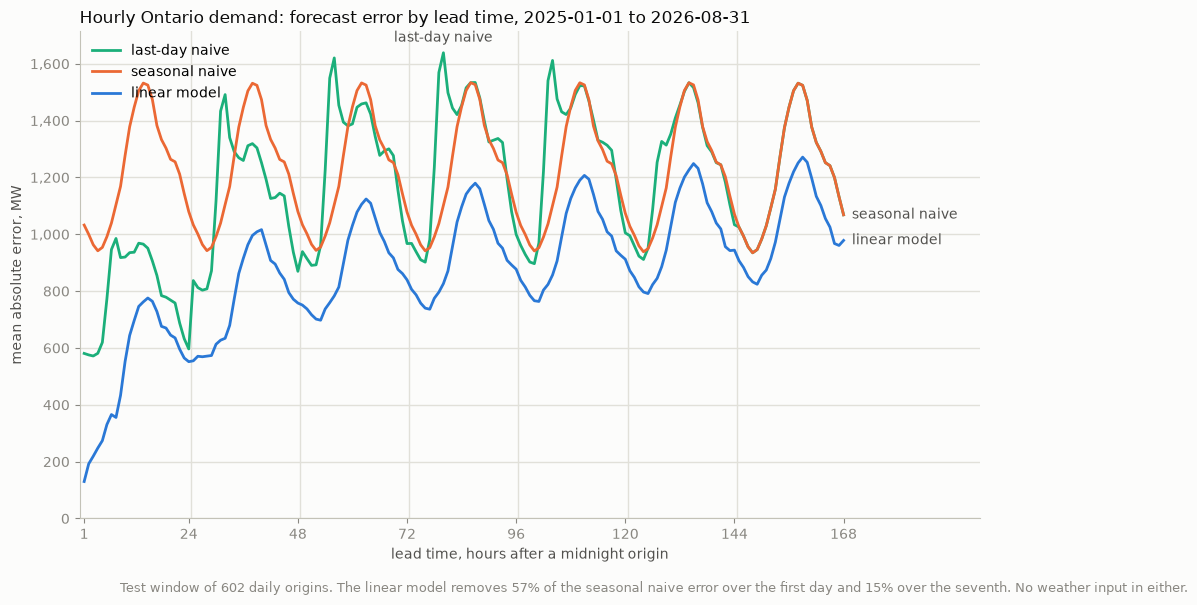

In [36]:
# The first chart: error by lead time for the baseline and the model, over the test window.
# Mean absolute error in megawatts on the y axis, lead hour on the x axis, with the day
# boundaries marked so the daily rhythm of the error is readable. The gap between the two
# lines is the skill, and where it narrows is where the model has stopped adding anything.
# Colours are the portfolio's validated colour-blind-safe set, and the labels ride the
# lines so identity never rests on colour alone.
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

INK, MUTED, GRID, BASE_LINE = "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
COL = {"linear model": "#2a78d6", "seasonal naive": "#eb6834", "last-day naive": "#1baf7a"}

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
leads = mae_by_lead.index.to_numpy()
for d_edge in range(24, HORIZON, 24):
    ax.axvline(d_edge + 0.5, color=GRID, linewidth=1, zorder=0)
for m in ("last-day naive", "seasonal naive", "linear model"):
    ax.plot(leads, mae_by_lead[m], color=COL[m], linewidth=2, solid_joinstyle="round", label=m, zorder=3)
    if m == "last-day naive":                     # its last day coincides with the seasonal naive, so label it at its own worst lead
        x_lab = int(mae_by_lead[m].idxmax())
        ax.annotate(m, xy=(x_lab, mae_by_lead[m].loc[x_lab]), xytext=(0, 8), textcoords="offset points",
                    ha="center", fontsize=10, color=INK)
    else:
        ax.annotate(m, xy=(leads[-1], mae_by_lead[m].iloc[-1]), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=10, color=INK)
ax.set_xlim(0, HORIZON + 30)
ax.set_ylim(0, None)
ax.set_xticks([1] + list(range(24, HORIZON + 1, 24)))
ax.set_xlabel("lead time, hours after a midnight origin", color=INK)
ax.set_ylabel("mean absolute error, MW", color=INK)
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", color=GRID, linewidth=1)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(BASE_LINE)
ax.tick_params(colors=MUTED)
ax.legend(loc="upper left", frameon=False, fontsize=10)
skill_1 = 100 * (1 - mae_by_lead["linear model"].iloc[:24].mean() / mae_by_lead["seasonal naive"].iloc[:24].mean())
skill_7 = 100 * (1 - mae_by_lead["linear model"].iloc[144:].mean() / mae_by_lead["seasonal naive"].iloc[144:].mean())
ax.set_title("Hourly Ontario demand: forecast error by lead time, " + str(TEST_START) + " to " + str(END), loc="left", color="#0b0b0b", fontsize=12)
fig.text(0.125, 0.005, "Test window of " + str(int(is_test.sum())) + " daily origins. The linear model removes "
         + format(skill_1, ".0f") + "% of the seasonal naive error over the first day and " + format(skill_7, ".0f")
         + "% over the seventh. No weather input in either.", fontsize=9, color=MUTED)
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig("error_by_horizon.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()


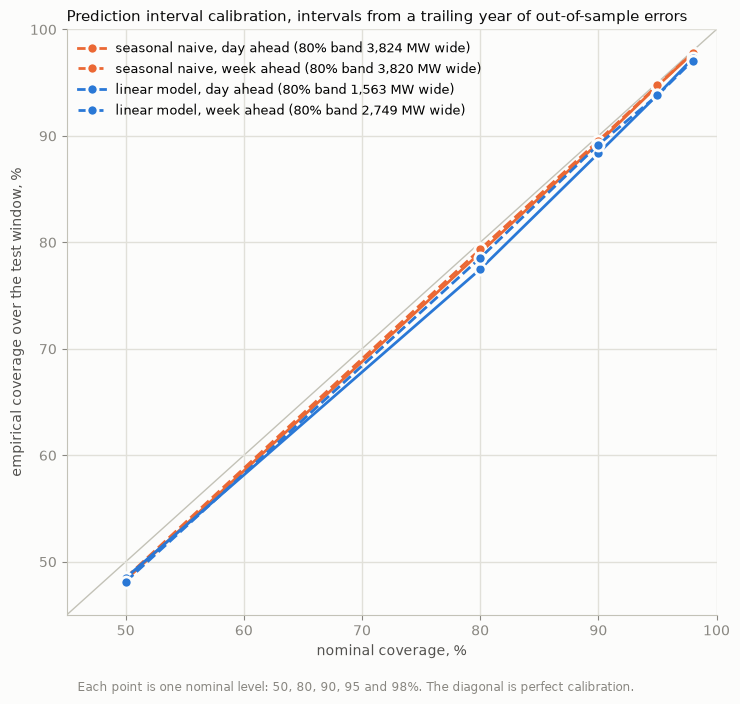

In [37]:
# The second chart: are the intervals calibrated. Nominal coverage across, empirical coverage
# up, one point per level; a well calibrated forecast sits on the diagonal. Colour is the
# model and line style is the horizon, so the two questions, which model and how far ahead,
# are on separate channels. Points below the line are intervals that promise more than they
# deliver, and the legend carries the width of each 80% band so calibration is read next to
# the sharpness it was bought with.
fig, ax = plt.subplots(figsize=(7.5, 7), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.plot([45, 100], [45, 100], color=BASE_LINE, linewidth=1, zorder=1)
styles = {"day ahead": "-", "week ahead": "--"}
for m in ("seasonal naive", "linear model"):
    for hz, ls in styles.items():
        sub = reliability[(reliability["model"] == m) & (reliability["horizon"] == hz)].sort_values("nominal")
        w80 = float(sub.loc[sub["nominal"] == 80, "mean_width_mw"].iloc[0])
        ax.plot(sub["nominal"], sub["empirical"], color=COL[m], linestyle=ls, linewidth=2, marker="o",
                markersize=8, markeredgecolor="#fcfcfb", markeredgewidth=2, zorder=3,
                label=m + ", " + hz + " (80% band " + format(w80, ",.0f") + " MW wide)")
ax.set_xlim(45, 100)
ax.set_ylim(45, 100)
ax.set_xlabel("nominal coverage, %", color=INK)
ax.set_ylabel("empirical coverage over the test window, %", color=INK)
ax.grid(color=GRID, linewidth=1)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(BASE_LINE)
ax.tick_params(colors=MUTED)
ax.legend(loc="upper left", frameon=False, fontsize=9.5)
ax.set_title("Prediction interval calibration, intervals from a trailing year of out-of-sample errors", loc="left", color="#0b0b0b", fontsize=11)
fig.text(0.11, 0.005, "Each point is one nominal level: 50, 80, 90, 95 and 98%. The diagonal is perfect calibration.",
         fontsize=8.5, color=MUTED)
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig("interval_calibration.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()


In [38]:
# The zonal report, loaded the same way as the provincial one and checked against it. Ten
# zones, a zone total, and a difference column that the publisher carries because the zones
# do not sum to the province. The first attempt at this load failed on one row: when the
# difference reaches four digits it is written with a thousands separator inside quotes,
# so a reader that guesses the quoting splits the row into sixteen fields. The quote
# character is therefore set rather than sniffed, the comma is stripped before the cast,
# and the rows that carried one are counted, because a separator that a cast turns into a
# null is the kind of defect that never raises. Then two checks before any of it is used:
# that the zones sum to the published zone total, and that the published difference equals
# the zone total minus the Ontario demand, on every row, with the rows behind the largest
# gaps printed so a reader can see what kind of row they are. The zonal fact is kept to the
# study years, because the dashboard is where it is used.
zonal_cols = {"date": "VARCHAR", "hour": "VARCHAR", "ontario_demand": "VARCHAR",
              "northwest": "VARCHAR", "northeast": "VARCHAR", "ottawa": "VARCHAR", "east": "VARCHAR",
              "toronto": "VARCHAR", "essa": "VARCHAR", "bruce": "VARCHAR", "southwest": "VARCHAR",
              "niagara": "VARCHAR", "west": "VARCHAR", "zone_total": "VARCHAR", "diff": "VARCHAR"}
ZONES = ["northwest", "northeast", "ottawa", "east", "toronto", "essa", "bruce", "southwest", "niagara", "west"]
NUMERIC_ZONAL = ["ontario_demand"] + ZONES + ["zone_total", "diff"]

con.execute("DROP TABLE IF EXISTS raw_zonal")
con.execute("CREATE TABLE raw_zonal (" + ", ".join(c + " VARCHAR" for c in zonal_cols) + ", source_file VARCHAR)")
for rec in zonal_manifest:
    con.execute("INSERT INTO raw_zonal SELECT *, ? FROM read_csv(?, skip = 4, header = false, quote = " + repr(chr(34))
                + ", escape = " + repr(chr(34)) + ", columns = " + repr(zonal_cols) + ")",
                [rec["file"], (data_dir / rec["file"]).as_posix()])

comma_rows = con.execute("""
    SELECT COUNT(*) AS rows_with_a_thousands_separator,
           """ + ", ".join("COUNT(*) FILTER (WHERE " + c + " LIKE '%,%') AS " + c for c in NUMERIC_ZONAL) + """
    FROM raw_zonal
    WHERE """ + " OR ".join(c + " LIKE '%,%'" for c in NUMERIC_ZONAL) + """
""").fetchdf()
print("rows whose numbers carry a thousands separator, by column:")
print(comma_rows.T.to_string(header=False))

con.execute("""
    CREATE OR REPLACE TABLE stg_zonal_hourly AS
    SELECT TRY_CAST(date AS TIMESTAMP) + to_hours(TRY_CAST(hour AS BIGINT) - 1) AS ts_start,
           TRY_CAST(date AS DATE) AS date, TRY_CAST(hour AS INTEGER) AS hour_ending,
           TRY_CAST(REPLACE(ontario_demand, ',', '') AS INTEGER) AS ontario_mw,
           """ + ", ".join("TRY_CAST(REPLACE(" + z + ", ',', '') AS INTEGER) AS " + z for z in ZONES) + """,
           TRY_CAST(REPLACE(zone_total, ',', '') AS INTEGER) AS zone_total,
           TRY_CAST(REPLACE(diff, ',', '') AS INTEGER) AS diff, source_file
    FROM raw_zonal
""")
zonal_checks = con.execute("""
    SELECT COUNT(*) AS rows,
           COUNT(*) FILTER (WHERE """ + " + ".join(ZONES) + """ <> zone_total)          AS zones_not_summing_to_total,
           MAX(ABS(""" + " + ".join(ZONES) + """ - zone_total))                            AS largest_zone_gap_mw,
           COUNT(*) FILTER (WHERE ABS(""" + " + ".join(ZONES) + """ - zone_total) > 5)     AS zone_gap_over_5_mw,
           COUNT(*) FILTER (WHERE zone_total - ontario_mw <> diff)                       AS diff_not_matching,
           MAX(ABS(zone_total - ontario_mw - diff))                                      AS largest_diff_gap_mw,
           COUNT(*) FILTER (WHERE ontario_mw IS NULL OR zone_total IS NULL OR diff IS NULL) AS failed_casts,
           ROUND(AVG(diff)) AS mean_diff_mw, MIN(diff) AS min_diff_mw, MAX(diff) AS max_diff_mw
    FROM stg_zonal_hourly
""").fetchdf()
print()
print(zonal_checks.T.to_string(header=False))

print()
print("the rows behind the extremes, largest zone gap first, then largest published difference:")
print(con.execute("""
    SELECT ts_start, ontario_mw, """ + " + ".join(ZONES) + """ AS zones_summed, zone_total, diff, source_file
    FROM stg_zonal_hourly ORDER BY ABS(""" + " + ".join(ZONES) + """ - zone_total) DESC LIMIT 3
""").fetchdf().to_string(index=False))
print(con.execute("""
    SELECT ts_start, ontario_mw, """ + ", ".join(ZONES) + """, zone_total, diff
    FROM stg_zonal_hourly ORDER BY ABS(diff) DESC LIMIT 3
""").fetchdf().to_string(index=False))

con.execute("""
    CREATE OR REPLACE TABLE dim_zone AS
    SELECT * FROM (VALUES """ + ", ".join("('" + z + "', '" + z.title() + "')" for z in ZONES) + """) AS t(zone_key, zone_name)
""")
con.execute("""
    CREATE OR REPLACE TABLE fct_demand_zonal AS
    SELECT ts_start, date, hour_ending, zone_key, zone_mw
    FROM stg_zonal_hourly
    UNPIVOT (zone_mw FOR zone_key IN (""" + ", ".join(ZONES) + """))
    WHERE date BETWEEN DATE '2024-01-01' AND ?
""", [END])
print()
print(con.execute("""
    SELECT z.zone_name, ROUND(AVG(f.zone_mw)) AS mean_mw_2025, ROUND(100.0 * SUM(f.zone_mw) / SUM(SUM(f.zone_mw)) OVER (), 1) AS share_pct
    FROM fct_demand_zonal f JOIN dim_zone z USING (zone_key)
    WHERE YEAR(f.date) = 2025
    GROUP BY 1 ORDER BY 2 DESC
""").fetchdf().to_string(index=False))


rows whose numbers carry a thousands separator, by column:
rows_with_a_thousands_separator  129
ontario_demand                     0
northwest                          0
northeast                          0
ottawa                             0
east                               0
toronto                            0
essa                               0
bruce                              0
southwest                          0
niagara                            0
west                               0
zone_total                         0
diff                             129

rows                        204695.0
zones_not_summing_to_total   72152.0
largest_zone_gap_mw            531.0
zone_gap_over_5_mw               4.0
diff_not_matching            29814.0
largest_diff_gap_mw             75.0
failed_casts                     0.0
mean_diff_mw                     2.0
min_diff_mw                 -18416.0
max_diff_mw                   9201.0

the rows behind the extremes, largest zone gap firs

In [39]:
# The star schema for the dashboard, written out as CSVs and reconciled against the tables
# they came from. Facts: the hourly demand series, the forecast at origin-lead-model grain,
# and zonal demand for the study years. Dimensions: date, zone, model, lead. The lead
# dimension carries the bucket labels so a slicer can group leads the way the score table
# does. Every export is read back and its line count checked, because an export that drops
# rows on the way out is the last place anyone looks.
pbi_dir = Path("../data/powerbi/ontario_demand")
pbi_dir.mkdir(parents=True, exist_ok=True)

con.execute("""
    CREATE OR REPLACE TABLE dim_model AS
    SELECT * FROM (VALUES
        ('seasonal naive', 'baseline', 'same hour, same weekday, one week earlier'),
        ('last-day naive', 'baseline', 'the origin day repeated for seven days'),
        ('linear model',   'model',    'one least squares fit per lead on lags, levels, day type and annual terms')
    ) AS t(model, model_kind, description)
""")
con.execute("""
    CREATE OR REPLACE TABLE dim_lead AS
    SELECT lead_hours,
           CAST(CEIL(lead_hours / 24.0) AS INTEGER)              AS target_day,
           ((lead_hours - 1) % 24) + 1                           AS target_hour_ending,
           CASE WHEN lead_hours <= 24  THEN 'day ahead'
                WHEN lead_hours <= 48  THEN 'two days ahead'
                WHEN lead_hours <= 144 THEN 'days 3 to 6'
                ELSE                        'week ahead' END      AS lead_bucket
    FROM range(1, 169) AS r(lead_hours)
""")

exports = {
    "fct_demand_hourly": "SELECT ts_start, date, hour_ending, ontario_mw, market_mw, filled FROM fct_demand_hourly WHERE date <= DATE '" + str(END) + "'",
    "fct_forecast":      "SELECT * FROM fct_forecast",
    "fct_demand_zonal":  "SELECT * FROM fct_demand_zonal",
    "dim_date":          "SELECT * FROM dim_date WHERE date <= DATE '" + str(END) + "'",
    "dim_zone":          "SELECT * FROM dim_zone",
    "dim_model":         "SELECT * FROM dim_model",
    "dim_lead":          "SELECT * FROM dim_lead",
}
export_mismatches = 0
for name, sql in exports.items():
    out = pbi_dir / (name + ".csv")
    con.execute("COPY (" + sql + ") TO '" + out.as_posix() + "' (HEADER, DELIMITER ',')")
    expected_rows = con.execute("SELECT COUNT(*) FROM (" + sql + ")").fetchone()[0]
    with open(out, "rb") as fh:
        written_rows = sum(1 for _ in fh) - 1
    ok = written_rows == expected_rows
    export_mismatches += 0 if ok else 1
    print(f"{name:<20} {written_rows:>10,} rows written  {out.stat().st_size:>12,} bytes  {'reconciled' if ok else 'MISMATCH against ' + str(expected_rows)}")
print("export mismatches:", export_mismatches)


fct_demand_hourly       213,336 rows written    11,013,489 bytes  reconciled
fct_forecast            303,408 rows written    32,924,748 bytes  reconciled
fct_demand_zonal        233,750 rows written    10,643,851 bytes  reconciled
dim_date                  9,009 rows written       416,780 bytes  reconciled
dim_zone                     10 rows written           167 bytes  reconciled
dim_model                     3 rows written           255 bytes  reconciled
dim_lead                    168 rows written         3,410 bytes  reconciled
export mismatches: 0


In [40]:
# The checks this notebook made along the way, gathered into one table so a reader can see
# every rule, what it expected, what it found and what was done about it without scrolling
# back. Each rule is a count of rows failing it. Where an expectation is structural it is
# stated, zero duplicates for instance; where it is a property of this pull it is measured
# and recorded, so a re-pull that moves it shows up here first. A block stops the build
# until a decision is written; a warn is flagged and carried; a note is recorded.
one_missing = int(len(missing_hours))
checks = [
    ("B1",  "BLOCK", "duplicate (date, hour) key in the staged demand table", 0,
     "SELECT COUNT(*) FROM (SELECT date, hour_ending FROM stg_demand_hourly GROUP BY 1, 2 HAVING COUNT(*) > 1)",
     "stop if any"),
    ("B2",  "BLOCK", "pulled file whose header differs from the one read before the pull", 0, header_drift,
     "stop and re-read the header"),
    ("B3",  "BLOCK", "pulled file whose inside year differs from the year in its name", 0, year_mismatch,
     "stop and check the listing"),
    ("B4",  "WARN",  "demand value that failed the integer cast", "measure",
     "SELECT COUNT(*) FROM stg_demand_hourly WHERE ontario_mw IS NULL OR market_mw IS NULL",
     "carried as null, filled on the spine if isolated"),
    ("B5",  "WARN",  "hour missing from the spine between the first and last published hour", "measure", one_missing,
     "filled with the mean of its neighbours and flagged"),
    ("B6",  "WARN",  "date before the window end with other than 24 rows", "measure",
     "SELECT COUNT(*) FROM (SELECT date FROM stg_demand_hourly WHERE date <= DATE '" + str(END) + "' GROUP BY 1 HAVING COUNT(*) <> 24)",
     "explained by B5; no clock-change days among them"),
    ("B7",  "WARN",  "hour where market demand is below Ontario demand", "measure",
     "SELECT COUNT(*) FROM stg_demand_hourly WHERE market_mw < ontario_mw",
     "recorded; Ontario demand is the target and is not adjusted"),
    ("B8",  "NOTE",  "hour below half of the same hour one week earlier", "measure",
     "SELECT COUNT(*) FROM stg_demand_hourly d JOIN stg_demand_hourly w ON w.ts_start = d.ts_start - INTERVAL 7 DAY WHERE d.ontario_mw < 0.5 * w.ontario_mw",
     "a real event, kept; outside every training window"),
    ("B9",  "BLOCK", "date in the hourly series with no calendar row", 0,
     "SELECT COUNT(*) FROM (SELECT DISTINCT date FROM stg_demand_hourly) s LEFT JOIN dim_date dd ON dd.date = s.date WHERE dd.date IS NULL",
     "stop; extend the calendar"),
    ("B10", "NOTE",  "filled hour in the fact table", one_missing,
     "SELECT COUNT(*) FROM fct_demand_hourly WHERE filled",
     "equals B5 by construction"),
    ("B11", "WARN",  "zonal row where the zones do not sum to the published zone total", "measure",
     "SELECT COUNT(*) FROM stg_zonal_hourly WHERE " + " + ".join(ZONES) + " <> zone_total",
     "recorded; zonal data is dashboard context only"),
    ("B12", "WARN",  "zonal row where zone total minus Ontario demand is not the published difference", "measure",
     "SELECT COUNT(*) FROM stg_zonal_hourly WHERE zone_total - ontario_mw <> diff",
     "recorded"),
    ("B13", "NOTE",  "year whose versioned copy differs from the plain yearly file", "measure", len(version_diffs),
     "the plain yearly file is the one loaded"),
    ("B14", "BLOCK", "day inside the test window missing from the series", 0,
     "SELECT COUNT(*) FROM dim_date dd LEFT JOIN (SELECT DISTINCT date FROM stg_demand_hourly) s ON s.date = dd.date WHERE dd.date BETWEEN DATE '" + str(TEST_START) + "' AND DATE '" + str(END) + "' AND s.date IS NULL",
     "stop; the window end must sit inside the published data"),
    ("B15", "BLOCK", "export whose written row count differs from its source table", 0, export_mismatches,
     "stop and re-export"),
    ("B16", "BLOCK", "scored origin with no model forecast", 0, int((~np.isfinite(F_model[is_calib | is_test])).sum()),
     "stop; the refit loop left a gap"),
    ("B17", "WARN",  "zonal row with a number written with a thousands separator", "measure",
     int(comma_rows["rows_with_a_thousands_separator"].iloc[0]),
     "quote character set, separator stripped before the cast"),
    ("B18", "BLOCK", "zonal value that failed the integer cast after the separator was stripped", 0,
     "SELECT COUNT(*) FROM stg_zonal_hourly WHERE ontario_mw IS NULL OR zone_total IS NULL OR diff IS NULL OR " + " OR ".join(z + " IS NULL" for z in ZONES),
     "stop; a value did not cast"),
]
rows = []
blocked = []
for cid, sev, rule, expected, probe, decision in checks:
    found = con.execute(probe).fetchone()[0] if isinstance(probe, str) else probe
    rows.append({"id": cid, "severity": sev, "rule": rule, "expected": expected, "found": found, "decision": decision})
    if sev == "BLOCK" and expected != "measure" and found != expected:
        blocked.append(cid + ": expected " + str(expected) + ", found " + str(found))
dq_assertions = pd.DataFrame(rows)
con.register("dq_assertions_df", dq_assertions)
con.execute("CREATE OR REPLACE TABLE dq_assertions AS SELECT * FROM dq_assertions_df")
print(dq_assertions.to_string(index=False))
if blocked:
    raise AssertionError("blocking checks failed: " + "; ".join(blocked))
print()
print("blocking checks passed:", sum(r["severity"] == "BLOCK" for r in rows), "| warns:", sum(r["severity"] == "WARN" for r in rows),
      "| notes:", sum(r["severity"] == "NOTE" for r in rows))


 id severity                                                                            rule expected  found                                                   decision
 B1    BLOCK                           duplicate (date, hour) key in the staged demand table        0      0                                                stop if any
 B2    BLOCK              pulled file whose header differs from the one read before the pull        0      0                                stop and re-read the header
 B3    BLOCK                 pulled file whose inside year differs from the year in its name        0      0                                 stop and check the listing
 B4     WARN                                       demand value that failed the integer cast  measure      0           carried as null, filled on the spine if isolated
 B5     WARN           hour missing from the spine between the first and last published hour  measure      1         filled with the mean of its neighbours and 